In [4]:
import pandas as pd

df = pd.read_csv("../data/external/part-00000-0af89d10-df53-44fd-b124-a8a496fd5023-c000.csv")
print("Forme:", df.shape)
print("Colonnes:", df.columns.tolist())
df.head(3)

Forme: (23003, 23)
Colonnes: ['resp_pkts', 'service', 'orig_ip_bytes', 'local_resp', 'missed_bytes', 'protocol', 'duration', 'conn_state', 'dest_ip', 'orig_pkts', 'community_id', 'resp_ip_bytes', 'dest_port', 'orig_bytes', 'local_orig', 'datetime', 'history', 'resp_bytes', 'uid', 'src_port', 'ts', 'src_ip', 'mitre_attack_tactics']


,resp_pkts,service,orig_ip_bytes,local_resp,missed_bytes,protocol,duration,conn_state,dest_ip,orig_pkts,...,orig_bytes,local_orig,datetime,history,resp_bytes,uid,src_port,ts,src_ip,mitre_attack_tactics
0,2,dns,186,False,0,udp,0.00228,SF,143.88.5.1,2,...,130.0,False,2022-02-10T03:58:29.979Z,Dd,130.0,CwO2bA321vyBxBjtxb,36073,1.644466e+09,143.88.5.12,Reconnaissance
1,2,dns,186,False,0,udp,0.00228,SF,143.88.5.1,2,...,130.0,False,2022-02-10T03:58:29.979Z,Dd,130.0,CwO2bA321vyBxBjtxb,36073,1.644466e+09,143.88.5.12,Reconnaissance
2,2,dns,186,False,0,udp,0.00228,SF,143.88.5.1,2,...,130.0,False,2022-02-10T03:58:29.979Z,Dd,130.0,CwO2bA321vyBxBjtxb,36073,1.644466e+09,143.88.5.12,Reconnaissance


In [5]:
# Quels types d'attaques sont dans le dataset ?
print(df['mitre_attack_tactics'].value_counts())

mitre_attack_tactics
none              18395
Reconnaissance     4608
Name: count, dtype: int64


In [6]:
print("=== VALEURS MANQUANTES ===")
print(df.isna().sum())
print("\n=== TYPES DE DONNÉES ===")
print(df.dtypes)

=== VALEURS MANQUANTES ===
resp_pkts                 0
service                 471
orig_ip_bytes             0
local_resp                0
missed_bytes              0
protocol                  0
duration                665
conn_state                0
dest_ip                   0
orig_pkts                 0
community_id              0
resp_ip_bytes             0
dest_port                 0
orig_bytes              665
local_orig                0
datetime                  0
history                 119
resp_bytes              665
uid                       0
src_port                  0
ts                        0
src_ip                    0
mitre_attack_tactics      0
dtype: int64

=== TYPES DE DONNÉES ===
resp_pkts                 int64
service                  object
orig_ip_bytes             int64
local_resp                 bool
missed_bytes              int64
protocol                 object
duration                float64
conn_state               object
dest_ip                  object
or

In [7]:
df.describe()

,resp_pkts,orig_ip_bytes,missed_bytes,duration,orig_pkts,resp_ip_bytes,dest_port,orig_bytes,resp_bytes,src_port,ts
count,23003.000000,23003.000000,23003.0,2.233800e+04,23003.000000,23003.000000,23003.000000,22338.000000,22338.000000,23003.000000,2.300300e+04
mean,0.386602,149.897970,0.0,1.057302e+00,1.971569,32.735904,149.131157,95.402095,22.246933,46190.409642,1.642502e+09
std,0.819321,92.104006,0.0,3.913625e+00,0.856483,69.672363,1630.601391,68.926667,48.018928,10374.340191,9.946338e+05
min,0.000000,0.000000,0.0,9.536743e-07,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.641708e+09
25%,0.000000,134.000000,0.0,1.502037e-05,2.000000,0.000000,53.000000,78.000000,0.000000,40015.500000,1.641900e+09
50%,0.000000,138.000000,0.0,2.098083e-05,2.000000,0.000000,53.000000,82.000000,0.000000,46243.000000,1.642085e+09
75%,0.000000,158.000000,0.0,1.958132e-03,2.000000,0.000000,53.000000,102.000000,0.000000,53415.000000,1.642274e+09
max,5.000000,1439.000000,0.0,6.305099e+01,12.000000,656.000000,63331.000000,1271.000000,600.000000,65502.000000,1.644466e+09


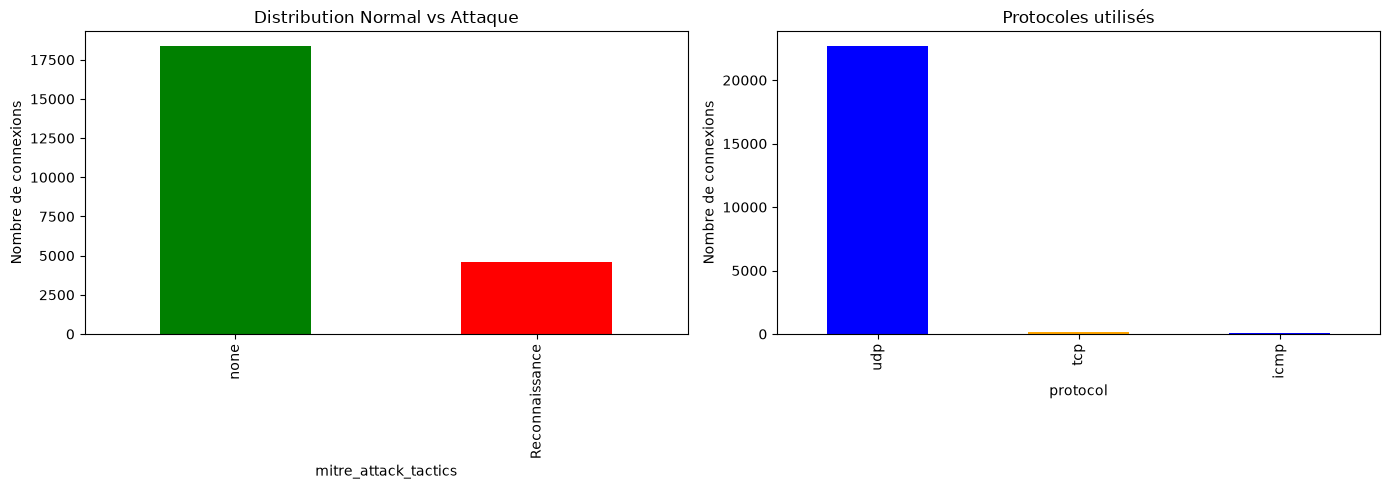

In [15]:
!pip install matplotlib

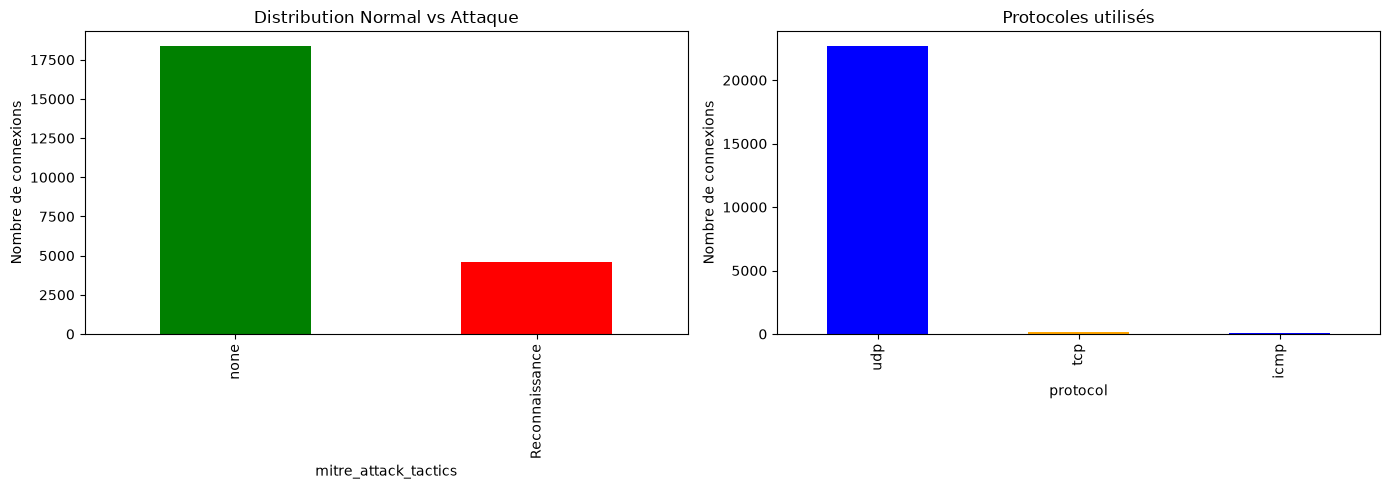

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Distribution des labels
df['mitre_attack_tactics'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title("Distribution Normal vs Attaque")
axes[0].set_ylabel("Nombre de connexions")

# Graphique 2 : Distribution des protocoles
df['protocol'].value_counts().plot(kind='bar', ax=axes[1], color=['blue', 'orange'])
axes[1].set_title("Protocoles utilisés")
axes[1].set_ylabel("Nombre de connexions")

plt.tight_layout()
plt.show()

In [17]:
# Lire le fichier binetflow du WannaCry
wannacry = pd.read_csv("../data/external/2017-05-15_win7.binetflow.txt")

print("Forme:", wannacry.shape)
print("Colonnes:", wannacry.columns.tolist())
wannacry.head(3)

Forme: (268, 15)
Colonnes: ['StartTime', 'Dur', 'Proto', 'SrcAddr', 'Sport', 'Dir', 'DstAddr', 'Dport', 'State', 'sTos', 'dTos', 'TotPkts', 'TotBytes', 'SrcBytes', 'Label']


,StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label
0,1970/01/01 01:00:10.347452,8.001000,ipv6-icmp,fe80::da58:d7ff:fe00:f72,133,->,fe80::69b0:5ca7:a676:2c5a,0,NRS,0.0,NaN,3,594,594,NaN
1,1970/01/01 01:00:10.347713,48.999378,arp,192.168.1.117,NaN,who,192.168.1.2,NaN,RSP,NaN,NaN,20,840,0,NaN
2,1970/01/01 01:00:10.757967,249.086441,ipv6-icmp,fd2d:ab8c:225::1,135,<->,fd2d:ab8c:225:0:51e6:bfd4:61a6:7837,0,NNS,0.0,0.0,4,336,250,NaN


In [18]:
print(wannacry['Label'].value_counts(dropna=False))

Label
NaN    268
Name: count, dtype: int64


In [19]:
notpetya = pd.read_csv("../data/external/2017-07-11_capture-win2.binetflow.txt")
print("NotPetya shape:", notpetya.shape)
print("NotPetya labels manquants:", notpetya['Label'].isna().sum(), "sur", len(notpetya))
print("-" * 30)

NotPetya shape: (80, 15)
NotPetya labels manquants: 80 sur 80
------------------------------


In [20]:
cryptowall = pd.read_csv("../data/external/2015-10-11_win3.binetflow.txt")
print("CryptoWall shape:", cryptowall.shape)
print("CryptoWall labels manquants:", cryptowall['Label'].isna().sum(), "sur", len(cryptowall))

CryptoWall shape: (54, 17)
CryptoWall labels manquants: 54 sur 54


In [21]:
# On lit notre fichier Winlogbeat (format JSON ligne par ligne)
vm_logs = pd.read_json("../data/raw/winlogbeat-output-20260706.ndjson", lines=True)

print("Forme de nos logs VM:", vm_logs.shape)
print("Colonnes:", vm_logs.columns.tolist())
vm_logs.head(2)

Forme de nos logs VM: (2077, 9)
Colonnes: ['@timestamp', '@metadata', 'event', 'log', 'message', 'host', 'ecs', 'agent', 'winlog']


,@timestamp,@metadata,event,log,message,host,ecs,agent,winlog
0,2026-07-06T14:06:09.012Z,"{'beat': 'winlogbeat', 'type': '_doc', 'versio...",{'action': 'Process Create (rule: ProcessCreat...,{'level': 'information'},Process Create:\nRuleName: -\nUtcTime: 2026-07...,{'name': 'DESKTOP-39R2AEI'},{'version': '8.0.0'},"{'type': 'winlogbeat', 'version': '8.18.3', 'e...","{'user': {'identifier': 'S-1-5-18', 'domain': ..."
1,2026-07-06T14:09:17.751Z,"{'beat': 'winlogbeat', 'type': '_doc', 'versio...","{'kind': 'event', 'provider': 'Microsoft-Windo...",{'level': 'information'},Process Create:\nRuleName: -\nUtcTime: 2026-07...,{'name': 'DESKTOP-39R2AEI'},{'version': '8.0.0'},"{'name': 'DESKTOP-39R2AEI', 'type': 'winlogbea...","{'user': {'identifier': 'S-1-5-18', 'domain': ..."


In [22]:
!python ../scripts/prepare_dataset.py

Démarrage de la préparation du dataset...
Traitement de la baseline système : ../data/raw/winlogbeat-output-20260706.ndjson
Traitement de la baseline réseau : ../data/external/part-00000-0af89d10-df53-44fd-b124-a8a496fd5023-c000.csv
Traitement du malware réseau : ../data/external/2017-05-15_win7.binetflow.txt
Traitement du malware réseau : ../data/external/2017-07-11_capture-win2.binetflow.txt
Traitement du malware réseau : ../data/external/2015-10-11_win3.binetflow.txt

Dataset final généré avec succès ! Shape: (14504, 13)

Distribution des labels :
label
0    14319
1      185
Name: count, dtype: int64


C:\Users\Admin\ransomware-detector\scripts\prepare_dataset.py:52: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  resampled = df.resample('10S').agg(
C:\Users\Admin\ransomware-detector\scripts\prepare_dataset.py:82: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  resampled = df.resample('10S').agg(
C:\Users\Admin\ransomware-detector\scripts\prepare_dataset.py:82: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  resampled = df.resample('10S').agg(
C:\Users\Admin\ransomware-detector\scripts\prepare_dataset.py:82: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  resampled = df.resample('10S').agg(


In [23]:
!pip install scikit-learn seaborn

Calcul de la robustesse (Cross-Validation 5-Fold)...
F1-Score moyen (CV) : 1.0000

=== RAPPORT DE CLASSIFICATION ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2864
           1       1.00      1.00      1.00        37

    accuracy                           1.00      2901
   macro avg       1.00      1.00      1.00      2901
weighted avg       1.00      1.00      1.00      2901

AUC-ROC Score : 1.0000


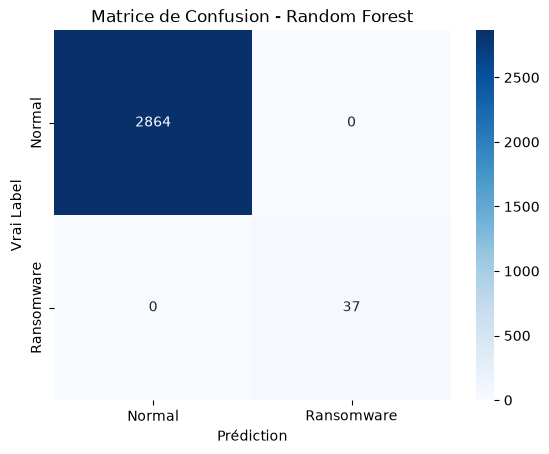

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Charger le dataset
df = pd.read_csv("../data/processed/dataset.csv")
X = df.drop(columns=['label'])
y = df['label']

# 2. Split 80% (train) / 20% (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialiser le Random Forest avec équilibrage des classes
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 4. Cross-Validation (5-fold) sur le train set
print("Calcul de la robustesse (Cross-Validation 5-Fold)...")
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1')
print(f"F1-Score moyen (CV) : {cv_scores.mean():.4f}")

# 5. Entraînement final
rf_model.fit(X_train, y_train)

# 6. Prédictions sur le test set (données jamais vues)
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# 7. Évaluation et métriques
print("\n=== RAPPORT DE CLASSIFICATION ===")
print(classification_report(y_test, y_pred))

print(f"AUC-ROC Score : {roc_auc_score(y_test, y_prob):.4f}")

# Afficher la Matrice de Confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Ransomware'], yticklabels=['Normal', 'Ransomware'])
plt.ylabel('Vrai Label')
plt.xlabel('Prédiction')
plt.title('Matrice de Confusion - Random Forest')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_26644\3223457981.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")


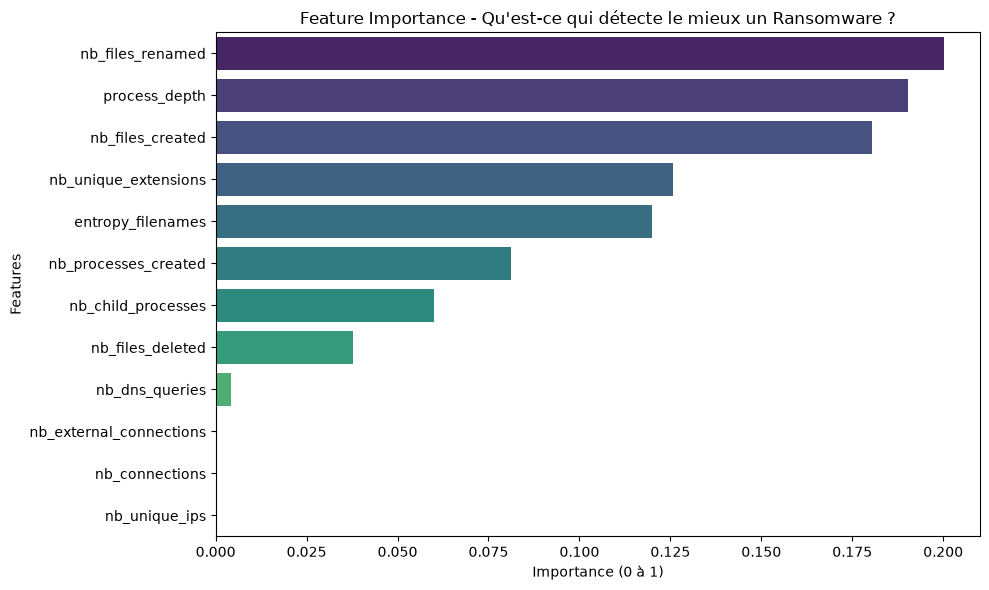

=== TOP 3 DES FEATURES LES PLUS IMPORTANTES ===
1. nb_files_renamed (0.2001)
2. process_depth (0.1902)
3. nb_files_created (0.1806)


In [26]:
import numpy as np

# Récupérer l'importance de chaque feature
importances = rf_model.feature_importances_
feature_names = X.columns

# Trier les features de la plus importante à la moins importante
indices = np.argsort(importances)[::-1]

# Créer un beau graphique
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")
plt.title("Feature Importance - Qu'est-ce qui détecte le mieux un Ransomware ?")
plt.xlabel("Importance (0 à 1)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# Afficher le Top 3 pour le rapport
print("=== TOP 3 DES FEATURES LES PLUS IMPORTANTES ===")
for i in range(3):
    print(f"{i+1}. {feature_names[indices[i]]} ({importances[indices[i]]:.4f})")

In [27]:
!pip install torch

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# 1. Normaliser les données (Obligatoire pour les réseaux de neurones)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Convertir en Tenseurs PyTorch (Format : batch_size, sequence_length, features)
X_train_tensor = torch.FloatTensor(X_train_scaled).unsqueeze(1)
y_train_tensor = torch.FloatTensor(y_train.values).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test_scaled).unsqueeze(1)
y_test_tensor = torch.FloatTensor(y_test.values).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 3. L'Architecture du Réseau LSTM
class RansomwareLSTM(nn.Module):
    def __init__(self, input_size):
        super(RansomwareLSTM, self).__init__()
        # 2 Couches LSTM
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=64, num_layers=2, batch_first=True, dropout=0.2)
        # Couche de décision finale
        self.fc = nn.Linear(64, 1)
        # Sortie entre 0 et 1 (probabilité)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])
        return self.sigmoid(out)

# 4. Initialisation (Adam Optimizer + BCELoss)
model = RansomwareLSTM(input_size=X.shape[1])
criterion = nn.BCELoss() # Binary Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. Entraînement
epochs = 5
print("Début de l'entraînement de l'LSTM...")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f}")

# 6. Évaluation sur le set de test
model.eval()
with torch.no_grad():
    y_pred_prob_lstm = model(X_test_tensor)
    y_pred_lstm = (y_pred_prob_lstm >= 0.5).float()

# On convertit en listes Python standard au lieu d'utiliser .numpy() pour éviter le crash
y_test_list = [x[0] for x in y_test_tensor.tolist()]
y_pred_list = [x[0] for x in y_pred_lstm.tolist()]

print("\n=== RAPPORT DE CLASSIFICATION (LSTM) ===")
print(classification_report(y_test_list, y_pred_list))

Début de l'entraînement de l'LSTM...
Epoch 1/5 - Loss: 0.1121
Epoch 2/5 - Loss: 0.0010
Epoch 3/5 - Loss: 0.0004
Epoch 4/5 - Loss: 0.0002
Epoch 5/5 - Loss: 0.0001

=== RAPPORT DE CLASSIFICATION (LSTM) ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2864
         1.0       1.00      1.00      1.00        37

    accuracy                           1.00      2901
   macro avg       1.00      1.00      1.00      2901
weighted avg       1.00      1.00      1.00      2901



In [30]:
import os
import joblib
import torch

# Créer le dossier pour les modèles
os.makedirs("../models", exist_ok=True)

# 1. Sauvegarder le modèle Random Forest (et le scaler pour les futures données)
joblib.dump(rf_model, "../models/random_forest_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
print("✅ Modèle Random Forest sauvegardé dans models/random_forest_model.pkl")

# 2. Sauvegarder le modèle LSTM (PyTorch)
torch.save(model.state_dict(), "../models/lstm_model.pth")
print("✅ Modèle LSTM sauvegardé dans models/lstm_model.pth")

✅ Modèle Random Forest sauvegardé dans models/random_forest_model.pkl
✅ Modèle LSTM sauvegardé dans models/lstm_model.pth
